# FAUST Point Cloud Dataset - Exploratory Data Analysis

This notebook explores the FAUST point cloud dataset for human identification.

**Contents:**
1. Load and inspect dataset
2. Visualize point clouds in 3D
3. Check data augmentation effects
4. Analyze class distribution
5. Examine point cloud statistics


In [1]:
# Import required libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from pathlib import Path
from scipy import stats

# Add src to path for imports
sys.path.append(str(Path('..').resolve() / 'src'))

from dataset import load_processed_dataset, load_faust_dataset, stratified_split_grouped, save_processed_dataset
from preprocessing import apply_augmentation, normalize_to_unit_sphere

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# 1. Load and inspect dataset
# Try loading processed data first; if not found, load from raw and save
processed_path = Path('../data/processed/faust_pc.npz')
raw_dir = '../data/raw'

if processed_path.exists():
    data, labels, filenames, metadata = load_processed_dataset(str(processed_path))
    samples_per_mesh = metadata.get('samples_per_mesh', 100)
else:
    print("Processed data not found. Loading from raw...")
    data, labels, filenames = load_faust_dataset(
        raw_dir, num_points=200, samples_per_mesh=100,
        use_fps=True, normalize_center=True, normalize_scale=True
    )
    samples_per_mesh = 100
    processed_path.parent.mkdir(parents=True, exist_ok=True)
    save_processed_dataset(data, labels, str(processed_path), filenames=filenames, 
                          normalized=True, samples_per_mesh=samples_per_mesh)

Loaded processed dataset from ../data/processed/faust_pc.npz
Data shape: (10000, 200, 3), Labels shape: (10000,)
Filenames: 10000 entries


In [3]:
# 2. Data Summary: Record counts, missing values, schema
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"\nRecord counts:")
print(f"  Total samples: {len(data):,}")
print(f"  Samples per mesh: {samples_per_mesh}")
print(f"  Unique meshes: {len(data) // samples_per_mesh}")
print(f"  Num points per sample: {data.shape[1]}")
print(f"  Coordinates per point: {data.shape[2]} (x, y, z)")

print(f"\nSchema:")
print(f"  data shape: {data.shape} (N_samples, num_points, 3)")
print(f"  labels shape: {labels.shape} (N_samples,)")
print(f"  data dtype: {data.dtype}")
print(f"  labels dtype: {labels.dtype}")

print(f"\nMissing values:")
missing_data = np.isnan(data).sum()
missing_labels = np.isnan(labels).sum() if labels.dtype in [np.float32, np.float64] else 0
print(f"  NaN in data: {missing_data}")
print(f"  NaN in labels: {missing_labels}")

print(f"\nValue ranges (x, y, z):")
print(f"  x: [{data[:,:,0].min():.4f}, {data[:,:,0].max():.4f}]")
print(f"  y: [{data[:,:,1].min():.4f}, {data[:,:,1].max():.4f}]")
print(f"  z: [{data[:,:,2].min():.4f}, {data[:,:,2].max():.4f}]")

DATA SUMMARY

Record counts:
  Total samples: 10,000
  Samples per mesh: 100
  Unique meshes: 100
  Num points per sample: 200
  Coordinates per point: 3 (x, y, z)

Schema:
  data shape: (10000, 200, 3) (N_samples, num_points, 3)
  labels shape: (10000,) (N_samples,)
  data dtype: float32
  labels dtype: int64

Missing values:
  NaN in data: 0
  NaN in labels: 0

Value ranges (x, y, z):
  x: [-0.7004, 0.7567]
  y: [-1.1654, 1.1696]
  z: [-0.6663, 0.7485]


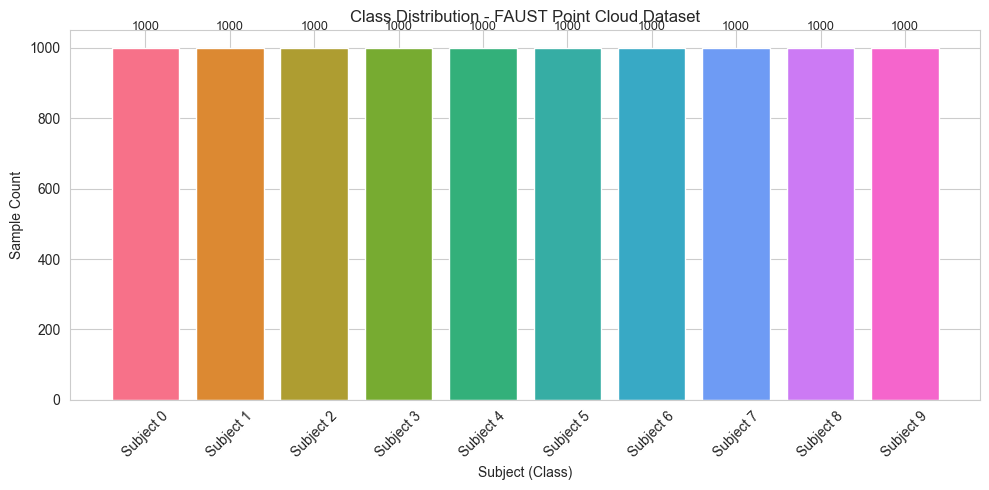

In [4]:
# 3. Class distribution (Bar chart)
Path('../results').mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 5))
unique, counts = np.unique(labels, return_counts=True)
bars = ax.bar([f'Subject {i}' for i in unique], counts, color=sns.color_palette('husl', len(unique)))
ax.set_xlabel('Subject (Class)')
ax.set_ylabel('Sample Count')
ax.set_title('Class Distribution - FAUST Point Cloud Dataset')
ax.tick_params(axis='x', rotation=45)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

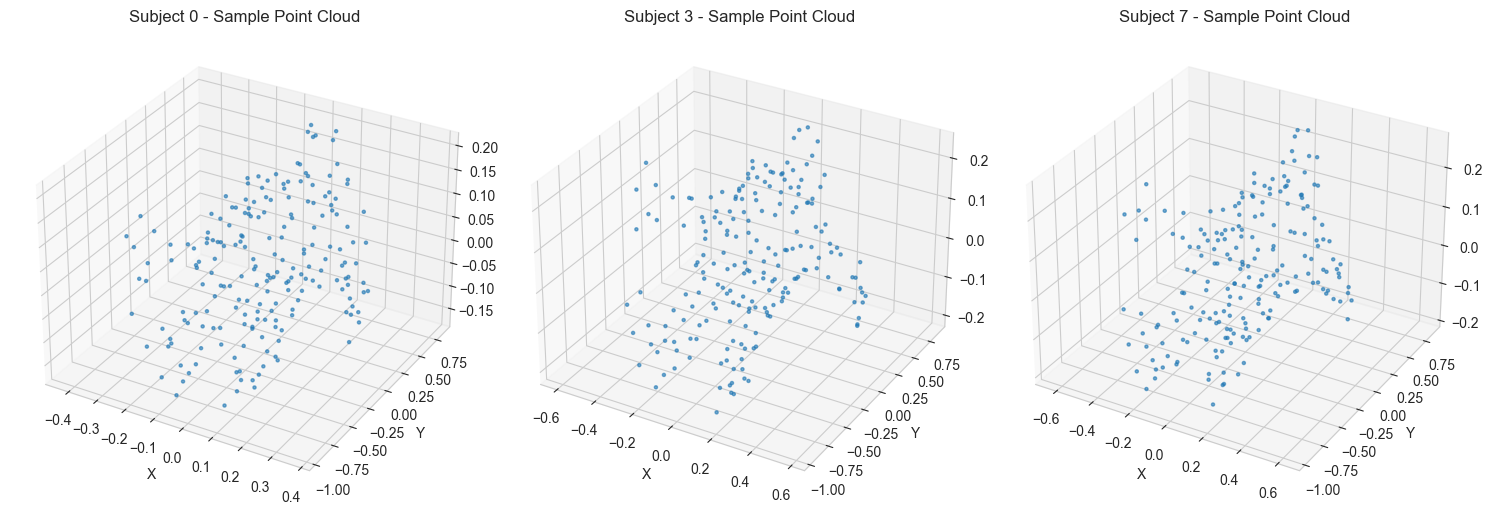

In [5]:
# 4. Visualize point clouds in 3D (samples from different subjects)
Path('../results').mkdir(parents=True, exist_ok=True)

fig = plt.figure(figsize=(15, 5))
for i, subj in enumerate([0, 3, 7]):  # Sample 3 subjects
    idx = np.where(labels == subj)[0][0]
    pc = data[idx]
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=5, alpha=0.6)
    ax.set_title(f'Subject {subj} - Sample Point Cloud')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.tight_layout()
plt.savefig('../results/eda_pointcloud_samples.png', dpi=150, bbox_inches='tight')
plt.show()

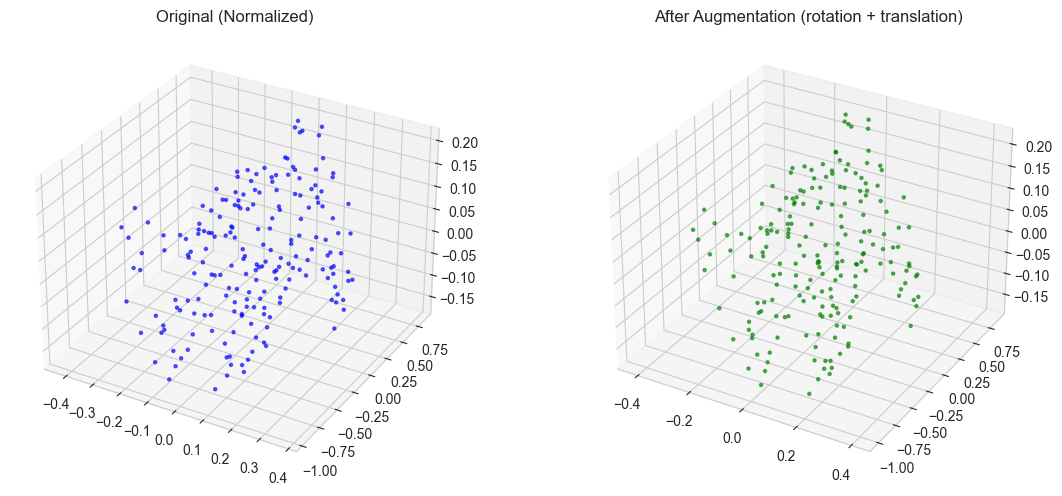

In [6]:
# 5. Check data augmentation effects (before vs after)
sample_pc = data[0].copy()
augmented = apply_augmentation(sample_pc, rotation=True, translation=True, normalize=True,
                               rotation_range=30, translation_range=0.2)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(sample_pc[:, 0], sample_pc[:, 1], sample_pc[:, 2], s=5, alpha=0.6, c='blue')
ax1.set_title('Original (Normalized)')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(augmented[:, 0], augmented[:, 1], augmented[:, 2], s=5, alpha=0.6, c='green')
ax2.set_title('After Augmentation (rotation + translation)')
plt.tight_layout()
plt.savefig('../results/eda_augmentation_effect.png', dpi=150, bbox_inches='tight')
plt.show()

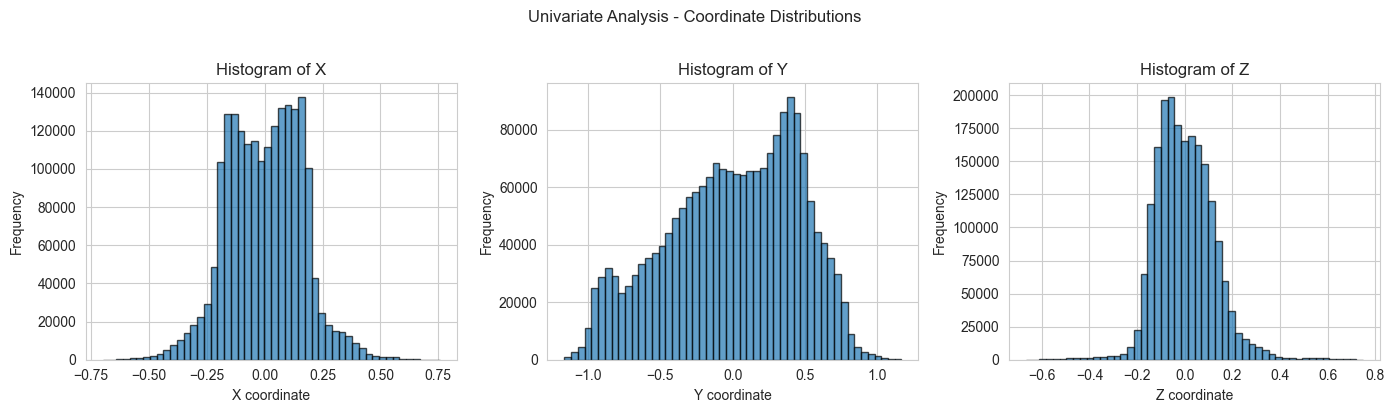

In [7]:
# 6. Univariate analysis - distribution of x, y, z coordinates
# Flatten all points across samples for coordinate-wise analysis
x_flat = data[:, :, 0].flatten()
y_flat = data[:, :, 1].flatten()
z_flat = data[:, :, 2].flatten()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, coord, name in zip(axes, [x_flat, y_flat, z_flat], ['X', 'Y', 'Z']):
    ax.hist(coord, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel(f'{name} coordinate')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Histogram of {name}')
plt.suptitle('Univariate Analysis - Coordinate Distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../results/eda_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

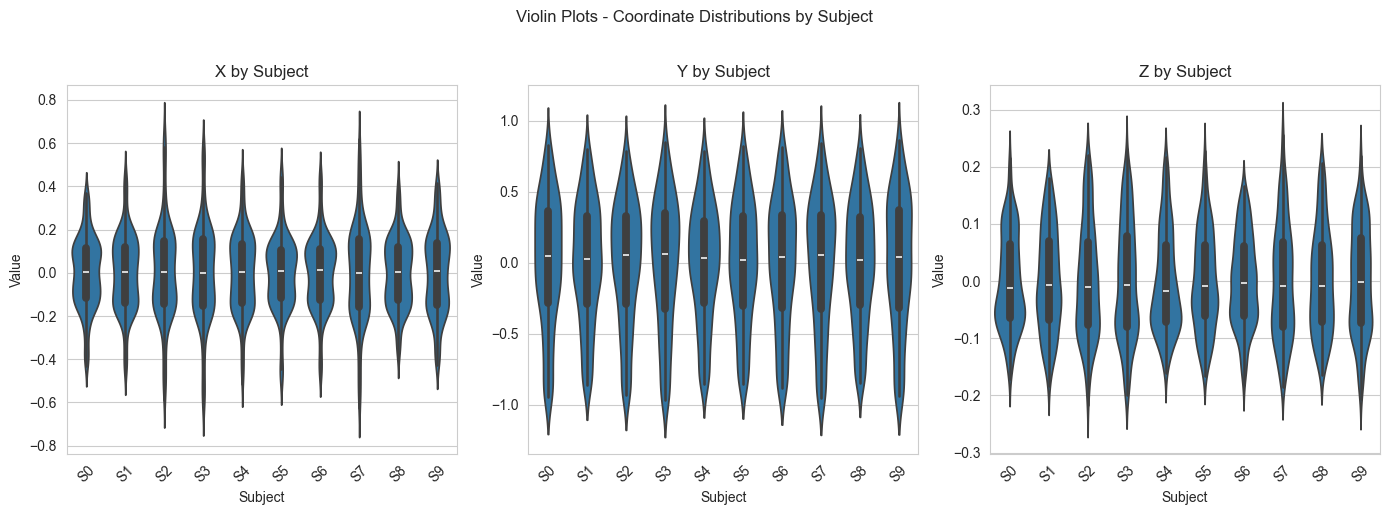

In [8]:
# 7. Violin plots - coordinate distributions by subject
df_violin = []
for i in range(min(10, len(np.unique(labels)))):
    mask = labels == i
    for j, coord in enumerate(['x', 'y', 'z']):
        vals = data[mask, :, j].flatten()
        df_violin.extend([{'Subject': f'S{i}', 'Coordinate': coord.upper(), 'Value': v} for v in vals[:500]])
import pandas as pd
df_v = pd.DataFrame(df_violin)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, coord in zip(axes, ['X', 'Y', 'Z']):
    sns.violinplot(data=df_v[df_v['Coordinate']==coord], x='Subject', y='Value', ax=ax)
    ax.set_title(f'{coord} by Subject')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Violin Plots - Coordinate Distributions by Subject', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../results/eda_violin.png', dpi=150, bbox_inches='tight')
plt.show()

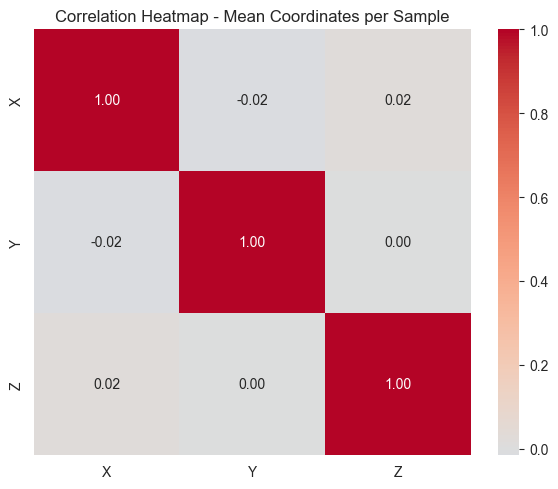

In [9]:
# 8. Bivariate analysis - correlation heatmap (mean x,y,z per sample)
# Compute per-sample statistics
mean_per_sample = data.mean(axis=1)  # (N, 3)
corr_matrix = np.corrcoef(mean_per_sample.T)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=['X', 'Y', 'Z'], yticklabels=['X', 'Y', 'Z'], ax=ax)
ax.set_title('Correlation Heatmap - Mean Coordinates per Sample')
plt.tight_layout()
plt.savefig('../results/eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

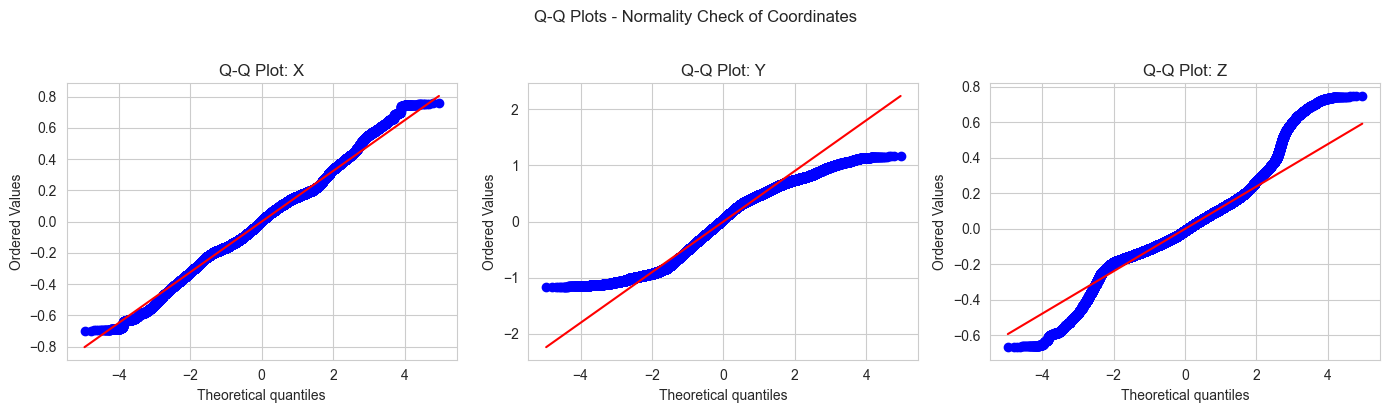

In [10]:
# 9. Q-Q plots - check normality of coordinate distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, coord, name in zip(axes, [x_flat, y_flat, z_flat], ['X', 'Y', 'Z']):
    stats.probplot(coord, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {name}')
plt.suptitle('Q-Q Plots - Normality Check of Coordinates', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../results/eda_qqplot.png', dpi=150, bbox_inches='tight')
plt.show()

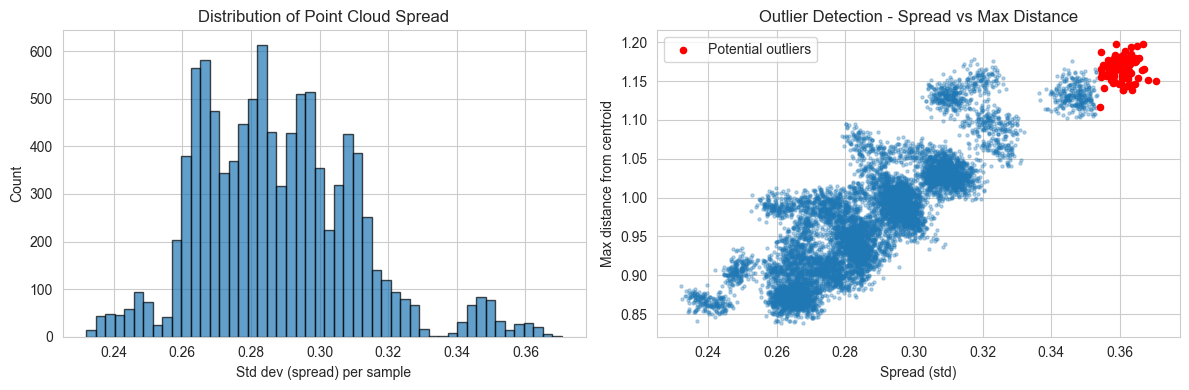

Potential outliers (top 1% by spread): 100 samples


In [11]:
# 10. Outlier analysis - point cloud statistics
# Per-sample: centroid distance, spread, etc.
centroids = data.mean(axis=1)
spreads = np.std(data, axis=(1, 2))  # Overall spread per sample
max_dist = np.max(np.linalg.norm(data - centroids[:, np.newaxis, :], axis=2), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(spreads, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Std dev (spread) per sample')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Point Cloud Spread')
axes[1].scatter(spreads, max_dist, alpha=0.3, s=5)
axes[1].set_xlabel('Spread (std)')
axes[1].set_ylabel('Max distance from centroid')
axes[1].set_title('Outlier Detection - Spread vs Max Distance')
# Mark potential outliers (e.g., top 1% by spread)
threshold = np.percentile(spreads, 99)
outlier_mask = spreads >= threshold
axes[1].scatter(spreads[outlier_mask], max_dist[outlier_mask], c='red', s=20, label='Potential outliers')
axes[1].legend()
plt.tight_layout()
plt.savefig('../results/eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Potential outliers (top 1% by spread): {outlier_mask.sum()} samples")